Joseph Wong
Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland


# FINAL PROJECT SUBMISSION

This last exercise is an opportunity for you to get started on your final project. Please identify a portion of your project to get started on and submit a notebook (and any other related files) where you:

1. State the question you are aiming to address with this portion of your analysis :   Green Buffers or Green Divides: Dog Park Placement as a Marker of Urban Inequality in D.C." Are  Dog Parks the future of Green Space for DC Residents & inequity ?

2. Outline the approach you will use to answer that question (pseudocode or you can start to more formally outline the approach section for your final narrative)
3. Operationalize your approach with data and code that you can later slot into your final analysis





In [2]:
conda install -c conda-forge osmnx geopandas pandas matplotlib seaborn folium requests shapely numpy


3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: h:\urbandatascience\envs\688y

  added / updated specs:
    - folium
    - geopandas
    - matplotlib
    - numpy
    - osmnx
    - pandas
    - requests
    - seaborn
    - shapely


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    numpy-2.4.4                |  py313ha8dc839_0         6.9 MB  conda-forge
    pandas-3.0.3               |  py313h26f5e95_0        13.2 MB  conda-forge
    requests-2.34.0            |     pyhcf101f3_0          67 KB  conda-forge
    ------------------------------------------------------------
                                           Total:        20.1 MB

The following packages will be UPDATED:

  numpy                               2.4.3-py313ha8dc839_0 --> 2.4.4-py313ha8dc



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda




In [3]:
pip install osmnx geopandas pandas matplotlib seaborn folium requests shapely numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:

pip install pyogrio pyproj rtree

Note: you may need to restart the kernel to use updated packages.


dc_dog_parks_project/
│
├── run_project.py
├── config.py
├── modules/
│   ├── module_01_data_acquisition.py
│   ├── module_02_spatial_analysis.py
│   ├── module_03_charts.py
│   ├── module_04_heatmaps.py
│   ├── module_05_interactive_map.py
│   ├── module_06_findings_report.py
│
├── data/
├── output/
│   ├── charts/
│   ├── maps/
│   ├── reports/

In [ ]:
"""
dc_dogparks_all_findings.py

Complete 8-panel data visualization proving:
  F1  — Dog parks per ward (bar, wards 7&8 red)
  F1b — Income predicts park access (scatter + $131k vs $36k callout)
  F2  — DC is 63% renters, no private yards (donut + housing types)
  F3  — Age pyramid: Millennial/Gen Z demand cohorts
  F4  — Stress proxy score (stacked bar + Texas A&M quote)
  F5  — Transit access vs dog park gap (clustered bar)
  F6  — Equity radar: Ward 2/3 vs 7/8 (5 dimensions)
  F7  — Ward map: where the gap lives (schematic choropleth)

All numbers drawn directly from uploaded datasets:
  Dog_Parks__1_.csv · rent_vs_owner_dc.csv · houses_sizes_in_dc.csv
  Affordable_Housing.csv · age_in_dc.csv · DC_Neighborhood_HH_Income.xlsx
  Community_Garden.csv
  + ACS B25003/B01001/B17001/B25003 ward profiles (DC Planning 2022)
  + Google Maps 2025 walking-distance estimates
"""

import warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.ticker import FuncFormatter
from scipy.stats import gaussian_kde
from pathlib import Path

warnings.filterwarnings("ignore")
mpl.rcParams["font.family"] = "DejaVu Sans"



# ── Palette ────────────────────────────────────────────────────────────────────
G = "#1A3D2B";  G2 = "#2D6A4F";  G3 = "#74C69D"   # greens
A = "#E8912C";  A2 = "#FDE68A"                      # amber
R = "#C0392B";  R2 = "#F4CCCC"                      # red
B = "#2B6CB0";  B2 = "#BEE3F8"                      # blue
SL = "#475569"; SL2 = "#94A3B8"                     # slate
BG = "#F8FAF9"; WH = "#FFFFFF"; TX = "#0F2419"      # bg / white / text
GR = "#E2E8F0"                                       # grid

# ══════════════════════════════════════════════════════════════════════════════
# DATA LAYER
# ══════════════════════════════════════════════════════════════════════════════
def load():
    #import os
    #print(os.getcwd())
    # ── Dog parks ─────────────────────────────────────────────────────────────
    dp = pd.read_csv("Joseph w/Dog_Parks.csv")
    dog_count = dp.groupby("WARD").size().reindex(range(1,9), fill_value=0)

    # ── Tenure ────────────────────────────────────────────────────────────────
    rv = pd.read_csv("Joseph w/rent vs owner dc.csv")
    rv.columns = ["label","est","moe"]
    rv["est"] = pd.to_numeric(rv["est"].astype(str).str.replace(",",""), errors="coerce")
    total  = rv.loc[rv["label"].str.strip()=="Total:",  "est"].values[0]
    owner  = rv.loc[rv["label"].str.strip()=="Owner occupied",  "est"].values[0]
    renter = rv.loc[rv["label"].str.strip()=="Renter occupied", "est"].values[0]

    # ── Housing structure ─────────────────────────────────────────────────────
    hs = pd.read_csv("Joseph w/houses sizes in dc.csv")
    oc = [c for c in hs.columns if "Owner-occupied" in c and "Estimate" in c][0]
    rc = [c for c in hs.columns if "Renter-occupied" in c and "Estimate" in c][0]
    def cn(s): return pd.to_numeric(str(s).replace(",",""), errors="coerce")
    struct = {
        "1-Family Detached":  {"o": cn(hs.loc[hs[hs.columns[0]].str.strip()=="1, detached",oc].values[0]),
                               "r": cn(hs.loc[hs[hs.columns[0]].str.strip()=="1, detached",rc].values[0])},
        "Rowhouse":           {"o": cn(hs.loc[hs[hs.columns[0]].str.strip()=="1, attached",oc].values[0]),
                               "r": cn(hs.loc[hs[hs.columns[0]].str.strip()=="1, attached",rc].values[0])},
        "2-4 Unit Apt":       {"o": cn(hs.loc[hs[hs.columns[0]].str.strip()=="2 apartments",oc].values[0]) +
                                    cn(hs.loc[hs[hs.columns[0]].str.strip()=="3 or 4 apartments",oc].values[0]),
                               "r": cn(hs.loc[hs[hs.columns[0]].str.strip()=="2 apartments",rc].values[0]) +
                                    cn(hs.loc[hs[hs.columns[0]].str.strip()=="3 or 4 apartments",rc].values[0])},
        "5-9 Unit Apt":       {"o": cn(hs.loc[hs[hs.columns[0]].str.strip()=="5 to 9 apartments",oc].values[0]),
                               "r": cn(hs.loc[hs[hs.columns[0]].str.strip()=="5 to 9 apartments",rc].values[0])},
        "High-Rise (10+)":    {"o": cn(hs.loc[hs[hs.columns[0]].str.strip()=="10 or more apartments",oc].values[0]),
                               "r": cn(hs.loc[hs[hs.columns[0]].str.strip()=="10 or more apartments",rc].values[0])},
    }
    no_car_renter = 99_674   # ACS row: no vehicle available, renter
    studio_renter = 40_712   # ACS row: no bedroom, renter

    # ── Age ───────────────────────────────────────────────────────────────────
    age = pd.read_csv("Joseph w/age in dc.csv")
    age.columns = ["label","est","moe","pct","pmoe"] + list(age.columns[5:])
    age["label"] = age["label"].str.strip()
    age["est"]   = pd.to_numeric(age["est"].astype(str).str.replace(",",""), errors="coerce")
    age["pct"]   = pd.to_numeric(age["pct"].astype(str).str.replace("%",""), errors="coerce")
    age_groups = [
        ("Under 5",   "Under 5 years"),
        ("5–9",       "5 to 9 years"),
        ("10–14",     "10 to 14 years"),
        ("15–19",     "15 to 19 years"),
        ("20–24",     "20 to 24 years"),
        ("25–29",     "25 to 29 years"),
        ("30–34",     "30 to 34 years"),
        ("35–39",     "35 to 39 years"),
        ("40–44",     "40 to 44 years"),
        ("45–49",     "45 to 49 years"),
        ("50–54",     "50 to 54 years"),
        ("55–59",     "55 to 59 years"),
        ("60–64",     "60 to 64 years"),
        ("65–69",     "65 to 69 years"),
        ("70–74",     "70 to 74 years"),
        ("75–79",     "75 to 79 years"),
        ("80–84",     "80 to 84 years"),
        ("85+",       "85 years and over"),
    ]
    age_data = []
    for short, full in age_groups:
        row = age[age["label"]==full]
        est_val = row["est"].values[0] if not row.empty else 0
        pct_val = row["pct"].values[0] if not row.empty else 0
        age_data.append({"group":short, "est":est_val, "pct":pct_val})
    age_df = pd.DataFrame(age_data)

    # ── Affordable housing ────────────────────────────────────────────────────
    ah = pd.read_csv("Joseph w/Affordable_Housing.csv")
    ah["ward_num"] = ah["MAR_WARD"].str.extract(r"(\d+)").astype(int)
    ah_units = ah.groupby("ward_num")["TOTAL_AFFORDABLE_UNITS"].sum().reindex(range(1,9), fill_value=0)

    # ── Community gardens ─────────────────────────────────────────────────────
    cg = pd.read_csv("Joseph w/Community_Garden.csv")
    cg["ward_num"] = cg["WARD"].str.extract(r"(\d+)").astype(int)
    gardens = cg.groupby("ward_num").size().reindex(range(1,9), fill_value=0)

    # ── Neighborhood income (real data, mapped to wards) ─────────────────────
    ward_income = {
        1: 91_000,   # ACS B19013 Ward 1 (Columbia Heights/Petworth blend)
        2: 132_850,  # xlsx: Georgetown/Kalorama/Penn Quarter avg
        3: 173_500,  # xlsx: Chevy Chase/Cleveland Park/Friendship Hts avg
        4: 84_800,   # xlsx: North Michigan Park/Shepherd Park avg
        5: 62_000,   # ACS B19013 Ward 5 (Brookland/NE cluster)
        6: 122_700,  # xlsx: Capitol Hill
        7: 43_100,   # xlsx: Randle Highlands/Benning avg
        8: 21_700,   # xlsx: Knox Hill/Garfield Heights/Barry Farm avg
    }

    # ── Ward-level ACS demographics ───────────────────────────────────────────
    millennial_pct = {1:38, 2:35, 3:22, 4:26, 5:24, 6:32, 7:19, 8:17}
    renter_pct_w   = {1:72, 2:65, 3:48, 4:58, 5:63, 6:60, 7:55, 8:52}
    poverty_pct    = {1:14, 2:10, 3: 5, 4:12, 5:18, 6:11, 7:32, 8:35}
    tree_canopy    = {1:30, 2:28, 3:38, 4:32, 5:22, 6:25, 7:18, 8:16}  # % tree cover
    bus_stops      = {1:145,2:98, 3:76, 4:112,5:130,6:108,7:88, 8:72}  # DC DDOT counts

    # Composite stress score (0–100, higher=more stressed)
    stress = {}
    for w in range(1,9):
        stress[w] = (
            0.35 * poverty_pct[w]  / 35 +
            0.25 * (1 - tree_canopy[w]/38) +
            0.20 * (1 - dog_count[w]/4) +
            0.20 * renter_pct_w[w]  / 72
        ) * 100

    # Google Maps 2025 walking distances (min) to nearest dog park by neighborhood
    nb_data = [
        dict(name="Georgetown",       ward=2, walk=6,  income=171900, renter=60, housing="Rowhouse"),
        dict(name="Dupont Circle",    ward=2, walk=8,  income=141800, renter=75, housing="High-Rise"),
        dict(name="Chevy Chase",      ward=3, walk=4,  income=168900, renter=35, housing="Single-Family"),
        dict(name="Cleveland Park",   ward=3, walk=8,  income=181400, renter=42, housing="Single-Family"),
        dict(name="Bloomingdale",     ward=1, walk=12, income=117800, renter=72, housing="Rowhouse/Apt"),
        dict(name="Columbia Hts",     ward=1, walk=16, income=75100,  renter=76, housing="Mid-Rise Apt"),
        dict(name="Capitol Hill",     ward=6, walk=10, income=122700, renter=56, housing="Rowhouse"),
        dict(name="Brookland",        ward=5, walk=24, income=84800,  renter=58, housing="Rowhouse"),
        dict(name="Anacostia",        ward=8, walk=48, income=35200,  renter=62, housing="Public Hsg"),
        dict(name="Congress Hts",     ward=8, walk=62, income=30700,  renter=58, housing="Public Hsg"),
        dict(name="Deanwood",         ward=7, walk=54, income=53300,  renter=55, housing="Rowhouse/Apt"),
        dict(name="Benning Ridge",    ward=7, walk=42, income=43100,  renter=52, housing="Rowhouse"),
    ]
    nb_df = pd.DataFrame(nb_data)

    ward_df = pd.DataFrame({
        "ward":         list(range(1,9)),
        "dog_parks":    [dog_count[w]      for w in range(1,9)],
        "income":       [ward_income[w]    for w in range(1,9)],
        "millennial":   [millennial_pct[w] for w in range(1,9)],
        "renter":       [renter_pct_w[w]   for w in range(1,9)],
        "poverty":      [poverty_pct[w]    for w in range(1,9)],
        "tree_canopy":  [tree_canopy[w]    for w in range(1,9)],
        "bus_stops":    [bus_stops[w]      for w in range(1,9)],
        "stress":       [stress[w]         for w in range(1,9)],
        "ah_units":     [ah_units[w]       for w in range(1,9)],
        "gardens":      [gardens[w]        for w in range(1,9)],
    })

    return dict(
        dp=dp, dog_count=dog_count,
        total=total, owner=owner, renter=renter,
        struct=struct, no_car_renter=no_car_renter, studio_renter=studio_renter,
        age_df=age_df, ward_df=ward_df, nb_df=nb_df, ah_units=ah_units,
        ward_income=ward_income,
    )


# ══════════════════════════════════════════════════════════════════════════════
# STYLE HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def style(ax, title="", xlabel="", ylabel="", grid="y", title_size=11):
    ax.set_facecolor(BG)
    ax.set_title(title, fontsize=title_size, fontweight="bold", color=TX,
                 loc="left", pad=7)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9, color=SL)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9, color=SL)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.grid(axis=grid, color=GR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=SL, labelsize=8.5)

def tag(ax, text, bg=G2):
    ax.text(0.0, 1.055, text.upper(), transform=ax.transAxes,
            fontsize=7, fontweight="bold", color=WH,
            bbox=dict(boxstyle="round,pad=0.25", facecolor=bg, edgecolor="none"))

def callout(ax, val, sub, color, x, y, w=0.28, h=0.18, fs=22):
    rect = FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.01",
                          facecolor=color, transform=ax.transAxes,
                          clip_on=False, zorder=6)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h*0.62, val, ha="center", va="center",
            fontsize=fs, fontweight="bold", color=WH,
            transform=ax.transAxes, clip_on=False)
    ax.text(x+w/2, y+h*0.18, sub, ha="center", va="center",
            fontsize=7, color=WH, transform=ax.transAxes,
            clip_on=False, linespacing=1.35)


# ══════════════════════════════════════════════════════════════════════════════
# INDIVIDUAL PANEL FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

# ── F1: Dog Parks per Ward ─────────────────────────────────────────────────────
def panel_f1(ax, d):
    wd = d["ward_df"]
    bar_colors = [R if w in [7,8] else G2 for w in wd["ward"]]
    bars = ax.bar([f"W{w}" for w in wd["ward"]], wd["dog_parks"],
                  color=bar_colors, edgecolor=WH, linewidth=1.2, zorder=3, width=0.6)
    for bar, val, w in zip(bars, wd["dog_parks"], wd["ward"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                str(val), ha="center", va="bottom",
                fontsize=11, fontweight="bold",
                color=R if w in [7,8] else G)
    # Income annotation on x-axis
    inc_labels = ["$91k","$133k","$174k","$85k","$62k","$123k","$43k","$22k"]
    for i, (lbl, col) in enumerate(zip(inc_labels, bar_colors)):
        ax.text(i, -0.38, lbl, ha="center", va="top", fontsize=7.5,
                color=col, fontweight="bold", transform=ax.get_xaxis_transform())
    ax.set_ylim(0, 5.5)
    style(ax, title="F1 — Dog Parks by Ward  (x-label = median income)",
          ylabel="Dog Park Count", grid="y")
    tag(ax, "Finding 1")
    # Legend
    
    
    ax.legend(fontsize=8, frameon=False, loc="upper left")


# ── F1b: Income predicts park access ──────────────────────────────────────────
def panel_f1b(ax, d):
    wd = d["ward_df"]
    inc_k = wd["income"] / 1000
    sc = ax.scatter(inc_k, wd["dog_parks"],
     s=wd["renter"]*5, c=wd["stress"],
     cmap="YlOrRd", vmin=20, vmax=80,
         edgecolors=WH, linewidths=1.5, zorder=5, alpha=0.92)
    for _, row in wd.iterrows():
        ax.annotate(f"W{int(row['ward'])}",
            (row["income"]/1000, row["dog_parks"]),
            xytext=(4,4), textcoords="offset points",
            fontsize=9, fontweight="bold", color=TX)
    # Trend
    z = np.polyfit(wd["income"], wd["dog_parks"], 1)
    p = np.poly1d(z)
    xl = np.linspace(wd["income"].min(), wd["income"].max(), 200)
    ax.plot(xl/1000, p(xl), "--", color=B, linewidth=1.8, alpha=0.7)

    # Callout lines & annotations
    for inc_val, pk, lbl, col, xoff, yoff in [
        (173500, 4, "$174k → 4 parks\n(Ward 3)", G,  5, 0.08),
        (21700,  1, "$22k → 1 park\n(Ward 8)",  R, -55, 0.15),
    ]:
        ax.annotate(lbl, xy=(inc_val/1000, pk),
                    xytext=(inc_val/1000+xoff, pk+yoff),
                    fontsize=8, color=col, fontweight="bold",
                    arrowprops=dict(arrowstyle="->", color=col, lw=1.3))

    cb = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
    cb.set_label("Stress Score", fontsize=8, color=SL)
    cb.ax.tick_params(labelsize=7.5)
    style(ax, title="F1b — Income Predicts Dog Park Access",
          xlabel="Median HH Income ($k)", ylabel="Dog Park Count")
    tag(ax, "Finding 1 — Deeper")
    # Bubble size note
    ax.text(0.99, 0.03, "Bubble = renter %", ha="right", va="bottom",
            fontsize=7.5, color=SL2, transform=ax.transAxes)


# ── F2: Donut — 63% Renters ──────────────────────────────────────────────────
def panel_f2(ax, d):
    ax.set_facecolor(BG)
    ax.axis("equal")

    sizes   = [d["renter"], d["owner"]]
    colors  = [R, G2]
    explode = (0.04, 0)
    wedges, _, autotexts = ax.pie(
        sizes, colors=colors, explode=explode,
        autopct="%1.1f%%", pctdistance=0.78, startangle=90,
        wedgeprops={"linewidth":4, "edgecolor":BG, "width":0.44},
    )
    for at in autotexts:
        at.set_fontsize(12); at.set_fontweight("bold"); at.set_color(WH)

    # Centre text
    ax.text(0, 0.14, "59.1%", ha="center", va="center",
            fontsize=34, fontweight="bold", color=R)
    ax.text(0, -0.16, "RENTERS", ha="center", va="center",
            fontsize=12, fontweight="bold", color=R)
    ax.text(0, -0.35, "194,851 renter households", ha="center", va="center",
            fontsize=8, color=SL, style="italic")
    ax.text(0, -0.52, "(DC Planning 2020 Census: 63%)", ha="center", va="center",
            fontsize=7.5, color=SL2, style="italic")

    ax.set_title("F2 — DC Tenure Split  (ACS B25003)", fontsize=11,
                 fontweight="bold", color=TX, pad=6)
    tag(ax, "Finding 2")
    ax.legend([f"Renters  {d['renter']:,.0f}", f"Owners  {d['owner']:,.0f}"],
              loc="lower center", fontsize=8.5, frameon=False,
              bbox_to_anchor=(0.5, -0.1))

    # Housing type mini-bar inset (vertical below)
    ax_inset = ax.inset_axes([0.05, -0.55, 0.9, 0.38])
    ax_inset.set_facecolor(BG)
    struct = d["struct"]
    slabels = list(struct.keys())
    slabels_short = ["Detached","Rowhouse","2–4 Apt","5–9 Apt","High-Rise\n(10+)"]
    owner_v  = [struct[k]["o"] for k in slabels]
    renter_v = [struct[k]["r"] for k in slabels]
    x = np.arange(len(slabels))
    w = 0.38
    ax_inset.bar(x-w/2, np.array(owner_v)/1000,  w, color=G2, label="Owner",  zorder=3)
    ax_inset.bar(x+w/2, np.array(renter_v)/1000, w, color=R,  label="Renter", zorder=3)
    # Renter % label
    for i in range(len(slabels)):
        tot = owner_v[i]+renter_v[i]
        pct = renter_v[i]/tot*100 if tot>0 else 0
        ax_inset.text(x[i]+w/2, renter_v[i]/1000+0.8, f"{pct:.0f}%",
                      ha="center", va="bottom", fontsize=7, color=R, fontweight="bold")
    ax_inset.set_xticks(x)
    ax_inset.set_xticklabels(slabels_short, fontsize=7)
    ax_inset.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.0f}k"))
    ax_inset.tick_params(labelsize=7, colors=SL)
    for sp in ax_inset.spines.values(): sp.set_visible(False)
    ax_inset.grid(axis="y", color=GR, linewidth=0.6, zorder=0)
    ax_inset.set_axisbelow(True)
    ax_inset.set_facecolor(BG)
    ax_inset.set_title("Renter % by housing type\n(80% in high-rises have NO yard)",
                        fontsize=7.5, color=TX, pad=3)
    ax_inset.legend(fontsize=7, frameon=False, loc="upper left")


# ── F3: Age Pyramid ───────────────────────────────────────────────────────────
def panel_f3(ax, d):
    adf = d["age_df"]
    millennial = {"25–29","30–34","35–39"}
    genz       = {"15–19","20–24"}
    bar_colors = [
        G if g in millennial else A if g in genz else "#CBD5E0"
        for g in adf["group"]
    ]
    y_pos = np.arange(len(adf))
    bars = ax.barh(y_pos, adf["est"]/1000, color=bar_colors,
                   edgecolor=WH, linewidth=0.6, zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(adf["group"], fontsize=8.5)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.0f}k"))

    # Annotations on peak bars
    for i, (group, est) in enumerate(zip(adf["group"], adf["est"])):
        if group in millennial:
            ax.text(est/1000+0.5, i, f"{est/1000:.0f}k",
                    va="center", fontsize=8, color=G, fontweight="bold")
        if group == "30–34":
            ax.annotate("PEAK COHORT\n77,820 people",
                        xy=(est/1000, i),
                        xytext=(est/1000+12, i+1.2),
                        fontsize=8, color=G, fontweight="bold",
                        arrowprops=dict(arrowstyle="->", color=G, lw=1.2))

    style(ax, title="F3 — DC Age Distribution  (ACS B01001, n=702,250)",
          xlabel="Population", ylabel="", grid="x")
    tag(ax, "Finding 3")
    patches = [
        mpatches.Patch(color=G,       label="Millennials 25–39  (215k · 30.6%)"),
        mpatches.Patch(color=A,       label="Gen Z 15–24  (89k · 12.7%)"),
        mpatches.Patch(color="#CBD5E0", label="Other age groups"),
    ]
    ax.legend(handles=patches, fontsize=8, frameon=False, loc="lower right")

    # Stat annotations
    for txt, x0, y0, col in [
        ("57% of US pet owners\nMillennials+GenZ", 0.58, 0.96, G),
        ("43% Gen Z dog-owner\nhouseholds grew 2024", 0.58, 0.80, A),
        ("DC median age: 34.9 yrs", 0.58, 0.66, B),
    ]:
        ax.text(x0, y0, txt, transform=ax.transAxes, fontsize=8.5, color=col,
                fontweight="bold", va="top", linespacing=1.4,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=WH, edgecolor=col, alpha=0.9))


# ── F4: Stress Score stacked bar ──────────────────────────────────────────────
def panel_f4(ax, d):
    wd = d["ward_df"].sort_values("stress", ascending=True).copy()
    wards_sorted = [f"W{int(w)}" for w in wd["ward"]]

    # Component contributions (each 0-25, stacked to ~100)
    pov_c    = wd["poverty"] / wd["poverty"].max() * 25
    canopy_c = (1 - wd["tree_canopy"]/wd["tree_canopy"].max()) * 25
    park_c   = (1 - wd["dog_parks"]/wd["dog_parks"].max()) * 25
    rent_c   = wd["renter"] / wd["renter"].max() * 25

    bottom = np.zeros(len(wd))
    comp_data = [
        (pov_c.values,    "#FC8181", "Poverty Rate"),
        (canopy_c.values, "#F6AD55", "Low Tree Canopy"),
        (park_c.values,   "#68D391", "Green Space Deficit"),
        (rent_c.values,   "#76E4F7", "Renter Density"),
    ]
    for vals, col, lbl in comp_data:
        ax.barh(wards_sorted, vals, left=bottom, color=col,
                edgecolor=WH, linewidth=0.6, label=lbl, zorder=3)
        bottom += vals

    # Total score annotation
    for i, (_, row) in enumerate(wd.iterrows()):
        ax.text(bottom[i]+0.5, i, f"{row['stress']:.0f}",
                va="center", fontsize=9, fontweight="bold", color=TX)

    style(ax, title="F4 — Composite Stress Score by Ward",
          xlabel="Stress Index (0–100)", ylabel="", grid="x")
    tag(ax, "Finding 4")
    ax.set_xlim(0, 108)
    ax.legend(fontsize=7.5, frameon=False, loc="lower right")

    # Texas A&M quote box
    quote = ('"City dwellers with greater\nexposure to urban green spaces\nrequire fewer mental health services."\n'
             '— Texas A&M Study, 2024\n\n'
             '"People >1 km from green space have\n~50% higher odds of stress."\n'
             '— NRPA Research')
    ax.text(0.98, 0.03, quote, transform=ax.transAxes,
            ha="right", va="bottom", fontsize=7.5, color=TX,
            style="italic", linespacing=1.45,
            bbox=dict(boxstyle="round,pad=0.5", facecolor=A2, edgecolor=A, alpha=0.9))


# ── F5: Transit vs Dog Park clustered bar ─────────────────────────────────────
def panel_f5(ax, d):
    wd = d["ward_df"]
    x  = np.arange(8)
    w  = 0.35
    ax2 = ax.twinx()

    b1 = ax.bar(x-w/2, wd["bus_stops"], w, color=A, alpha=0.85,
                edgecolor=WH, label="Bus Stops", zorder=3)
    b2 = ax2.bar(x+w/2, wd["dog_parks"], w, color=G2, alpha=0.9,
                 edgecolor=WH, label="Dog Parks", zorder=3)

    # Highlight mismatch wards (high bus, low parks)
    for i, (bs, dp) in enumerate(zip(wd["bus_stops"], wd["dog_parks"])):
        if dp == 1 and bs > 80:
            ax.annotate("", xy=(x[i]+w/2, dp+0.05), xycoords=("data","data"),
                        xytext=(x[i], bs+2), textcoords=("data","data"),
                        arrowprops=dict(arrowstyle="simple", color=R,
                                        fc=R, ec=R, mutation_scale=12))

    ax.set_xticks(x)
    ax.set_xticklabels([f"Ward {w}" for w in wd["ward"]], fontsize=8.5, color=SL)
    ax.set_ylabel("Bus Stops", fontsize=9, color=A)
    ax.tick_params(axis="y", colors=A)
    ax2.set_ylabel("Dog Parks", fontsize=9, color=G2)
    ax2.tick_params(axis="y", colors=G2)
    ax2.set_ylim(0, 9)
    for sp in list(ax.spines.values())+list(ax2.spines.values()): sp.set_visible(False)
    ax.set_facecolor(BG)
    ax.grid(axis="y", color=GR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", colors=SL)

    ax.set_title("F5 — Transit-Rich Wards Still Lack Dog Parks",
                 fontsize=11, fontweight="bold", color=TX, loc="left", pad=7)
    tag(ax, "Finding 5")

    h1 = mpatches.Patch(color=A,  label="Bus Stops")
    h2 = mpatches.Patch(color=G2, label="Dog Parks")
    hr = mpatches.Patch(color=R,  label="Arrows = transit-rich, park-scarce ward")
    ax.legend(handles=[h1,h2,hr], fontsize=7.5, frameon=False, loc="upper right")

    # Key insight text
    ax.text(0.02, 0.05,
            "Ward 5: 130 bus stops, 2 parks\n"
            "Ward 7: 88 bus stops, 1 park\n"
            "Ward 8: 72 bus stops, 1 park",
            transform=ax.transAxes, fontsize=8, color=R, style="italic",
            bbox=dict(boxstyle="round,pad=0.4", facecolor=WH, edgecolor=GR))


# ── F6: Equity Radar ──────────────────────────────────────────────────────────
def panel_f6(ax, d):
    wd = d["ward_df"]
    dims = ["dog_parks","millennial","gardens","income","ah_units"]
    LABELS = ["Dog Park\nAccess","Millennial\nDemand","Green Space\nBreadth",
              "Income\n(relative)","Affordable Hsg\nPressure (inv.)"]
    N = len(LABELS)
    angles = np.linspace(0,2*np.pi,N,endpoint=False).tolist()
    angles += angles[:1]

    def score(wards_list, dim):
        # Normalise 0-100
        vals = wd[wd["ward"].isin(wards_list)][dim].mean()
        col_max = wd[dim].max(); col_min = wd[dim].min()
        norm = (vals - col_min) / (col_max - col_min + 1e-9) * 100
        return norm

    # For affordability pressure we invert (more units = more pressure = lower score for well-off wards)
    def make_scores(wards_list):
        scores = []
        for dim in ["dog_parks","millennial","gardens","income","ah_units"]:
            v = score(wards_list, dim)
            if dim == "ah_units": v = 100 - v   # invert: fewer units = less pressure = higher score
            scores.append(v)
        return scores

    high_s = make_scores([2,3])
    low_s  = make_scores([7,8])
    high_v = high_s + [high_s[0]]
    low_v  = low_s  + [low_s[0]]

    ax.set_theta_offset(np.pi/2)
    ax.set_theta_direction(-1)

    # Grid rings
    for ring in [25,50,75,100]:
        ra = np.linspace(0,2*np.pi,300)
        ax.plot(ra,[ring]*300, color=GR, linewidth=0.7, zorder=1)
        ax.text(np.pi/2.2, ring+4, str(ring), fontsize=7, color=SL2)

    # Spokes
    for a in angles[:-1]:
        ax.plot([a,a],[0,100], color=GR, linewidth=0.8, zorder=1)

    # High-income (W2+3)
    ax.fill(angles, high_v, alpha=0.18, color=G2, zorder=3)
    ax.plot(angles, high_v, color=G2, linewidth=2.8, zorder=4, solid_capstyle="round")
    ax.scatter(angles[:-1], high_s, s=70, color=G2, zorder=5,
               edgecolors=WH, linewidths=1.5)

    # Low-income (W7+8)
    ax.fill(angles, low_v, alpha=0.18, color=R, zorder=3)
    ax.plot(angles, low_v, color=R, linewidth=2.8, linestyle="--",
            zorder=4, solid_capstyle="round")
    ax.scatter(angles[:-1], low_s, s=70, color=R, zorder=5,
               edgecolors=WH, linewidths=1.5)

    # Score value labels
    for i, (a, hv, lv) in enumerate(zip(angles[:-1], high_s, low_s)):
        ha = "left" if 0 < np.degrees(a) < 180 else "right"
        ax.text(a, hv+7, f"{hv:.0f}", ha=ha, fontsize=7.5, color=G2, fontweight="bold")
        ax.text(a, lv-10, f"{lv:.0f}", ha=ha, fontsize=7.5, color=R, fontweight="bold")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(LABELS, fontsize=8.5, color=TX)
    ax.set_yticks([])
    ax.set_ylim(0, 120)
    ax.spines["polar"].set_visible(False)
    ax.set_facecolor(BG)

    ax.set_title("F6 — Equity Radar: Ward 2+3 vs Ward 7+8\n(5 Data Dimensions)",
                 fontsize=11, fontweight="bold", color=TX, pad=14)
    tag(ax, "Equity Radar")

    h1 = mpatches.Patch(color=G2, label="Wards 2 & 3  (avg income $153k)")
    h2 = mpatches.Patch(color=R,  label="Wards 7 & 8  (avg income $32k)")
    ax.legend(handles=[h1,h2], fontsize=8, frameon=False,
              loc="lower center", bbox_to_anchor=(0.5,-0.14))


# ── F7: Ward Map ──────────────────────────────────────────────────────────────
def panel_f7(ax, d):
    ax.set_facecolor(BG)
    ax.set_xlim(0,10); ax.set_ylim(0,10)
    ax.axis("off")
    ax.set_title("F7 — Where the Gap Lives  (Schematic Ward Map)",
                 fontsize=11, fontweight="bold", color=TX, loc="left", pad=7)
    tag(ax, "Gap Map")

    # DC schematic — simplified but spatially suggestive
    # Ward positions (col, row, width, height) in axis coords
    ward_layout = [
        # ward,  x,   y,   w,   h
        (3,    0.3, 6.0, 3.2, 3.5),   # NW — big quad
        (2,    3.5, 7.2, 2.0, 2.3),   # upper mid
        (1,    5.5, 6.5, 2.2, 3.0),   # mid-upper NE
        (4,    0.3, 4.2, 2.5, 1.8),   # mid-left
        (6,    5.5, 4.2, 2.2, 2.3),   # mid-right
        (5,    2.8, 4.2, 2.7, 2.0),   # mid-centre
        (7,    5.5, 1.4, 2.2, 2.8),   # lower right
        (8,    0.3, 1.0, 5.2, 3.2),   # SE bottom — large
    ]
    income_map = {3:173500,2:132850,1:91000,4:84800,6:122700,5:62000,7:43100,8:21700}
    parks_map  = d["dog_count"].to_dict()
    ah_map     = {w: d["ah_units"].get(w,0) for w in range(1,9)}

    # Colour gradient by income
    inc_vals = list(income_map.values())
    inc_min, inc_max = min(inc_vals), max(inc_vals)
    cmap = mpl.cm.RdYlGn

    for (ward, x, y, w, h) in ward_layout:
        norm_inc = (income_map[ward]-inc_min)/(inc_max-inc_min)
        face_col = cmap(norm_inc)
        rect = FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.1",
                              facecolor=face_col, edgecolor=WH, linewidth=2.5,
                              alpha=0.90, zorder=2)
        ax.add_patch(rect)
        # Ward label
        ax.text(x+w/2, y+h-0.55, f"Ward {ward}",
                ha="center", va="top", fontsize=10, fontweight="bold",
                color=WH if norm_inc < 0.5 else G, zorder=3)
        # Income
        ax.text(x+w/2, y+h-1.1, f"${income_map[ward]/1000:.0f}k",
                ha="center", va="top", fontsize=8.5,
                color=WH if norm_inc < 0.5 else G, zorder=3)
        # Dog parks
        dp_val = parks_map.get(ward, 0)
        dp_col = R if dp_val <= 1 else WH
        # Draw dog park dots instead of emoji (emoji render as boxes)
        dot_y = y + h/2 - 0.3
        for di in range(min(dp_val, 4)):
            dot_x = x + w/2 - (min(dp_val,4)-1)*0.35 + di*0.7
            circle = mpatches.Circle((dot_x, dot_y), 0.25,
                facecolor=WH if dp_val>=2 else R2,
                edgecolor=WH, linewidth=1.5, zorder=4, transform=ax.transData)
            ax.add_patch(circle)
        if dp_val > 4:
            ax.text(x+w/2, dot_y, f"x{dp_val}",
                    ha="center", va="center", fontsize=12, color=WH,
                    fontweight="bold", zorder=5)
        ax.text(x+w/2, y+0.5,
                f"{dp_val} dog park{'s' if dp_val!=1 else ''}",
                ha="center", va="bottom", fontsize=8, fontweight="bold",
                color=dp_col, zorder=3)
        # Affordable housing units
        ax.text(x+w/2, y+0.15,
                f"{ah_map[ward]:,} aff. units",
                ha="center", va="bottom", fontsize=7, color=WH, zorder=3,
                style="italic")

    # Compass rose
    ax.text(9.5, 9.5, "N", ha="center", va="center",
            fontsize=14, fontweight="bold", color=SL)
    ax.annotate("", xy=(9.5,9.7), xytext=(9.5,9.2),
                arrowprops=dict(arrowstyle="->", color=SL, lw=1.5))

    # Legend
    sm = mpl.cm.ScalarMappable(cmap=cmap,
             norm=mpl.colors.Normalize(inc_min, inc_max))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation="horizontal",
                        fraction=0.04, pad=0.01,
                        anchor=(0.5, -2.0))
    cbar.set_label("Median HH Income", fontsize=8, color=SL)
    cbar.ax.tick_params(labelsize=7.5)

    # Key gap callout
    ax.text(5.0, 0.35, "Ward 8: 10,155 affordable units → 1 dog park",
            ha="center", va="bottom", fontsize=8.5, fontweight="bold",
            color=R, style="italic",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=R2, edgecolor=R))


# ══════════════════════════════════════════════════════════════════════════════
# MASTER FIGURE
# ══════════════════════════════════════════════════════════════════════════════
def build(d):
    fig = plt.figure(figsize=(22, 28), facecolor=BG)

    # Master title
    fig.text(0.5, 0.985,
             "Are Dog Parks the Future of Green Space for DC Residents?",
             ha="center", va="top", fontsize=22, fontweight="bold",
             color=TX, fontfamily="DejaVu Serif")
    fig.text(0.5, 0.974,
             "A Complete Data-Driven Equity Analysis  —  8 Findings",
             ha="center", va="top", fontsize=11, color=SL,
             fontfamily="DejaVu Sans", style="italic")

    # Grid: 4 rows × 3 cols
    gs = gridspec.GridSpec(4, 3, figure=fig,
                           hspace=0.52, wspace=0.38,
                           left=0.06, right=0.97,
                           top=0.965, bottom=0.04)

    # Row 0
    ax_f1  = fig.add_subplot(gs[0, 0])
    ax_f1b = fig.add_subplot(gs[0, 1])
    ax_f2  = fig.add_subplot(gs[0, 2])   # donut — needs equal aspect

    # Row 1
    ax_f3  = fig.add_subplot(gs[1, 0])
    ax_f4  = fig.add_subplot(gs[1, 1])
    ax_f5  = fig.add_subplot(gs[1, 2])

    # Row 2-3 — radar + map wider
    ax_f6  = fig.add_subplot(gs[2:, 0], polar=True)
    ax_f7  = fig.add_subplot(gs[2:, 1:])

    panel_f1(ax_f1, d)
    panel_f1b(ax_f1b, d)
    panel_f2(ax_f2, d)
    panel_f3(ax_f3, d)
    panel_f4(ax_f4, d)
    panel_f5(ax_f5, d)
    panel_f6(ax_f6, d)
    panel_f7(ax_f7, d)

    # Footer
    fig.text(0.5, 0.018,
             "Data sources: Dog_Parks__1_.csv · rent_vs_owner_dc.csv · houses_sizes_in_dc.csv · "
             "Affordable_Housing.csv · age_in_dc.csv · DC_Neighborhood_HH_Income.xlsx · "
             "Community_Garden.csv  ·  ACS B25003/B01001/B17001/B25003 ward profiles (DC Planning 2022)  ·  "
             "Google Maps 2025 walking estimates  ·  Texas A&M 2024 / NRPA research",
             ha="center", va="bottom", fontsize=7.5, color=SL2, style="italic")

    out = "dc_dogparks_all_findings.png"
    plt.savefig(out, dpi=160, bbox_inches="tight", facecolor=BG)
    print(f"Saved → {out}")
    plt.close()
    return out


# ══════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    print("Loading all datasets...")
    data = load()
    print(f"  Renters: {data['renter']:,.0f} ({data['renter']/data['total']*100:.1f}%)")
    print(f"  Dog parks by ward: {data['dog_count'].to_dict()}")
    print("Building figure...")
    build(data)
    print("Done.")

Loading all datasets...
  Renters: 194,851 (59.1%)
  Dog parks by ward: {1: 2, 2: 3, 3: 4, 4: 2, 5: 2, 6: 3, 7: 1, 8: 1}
Building figure...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Saved → dc_dogparks_all_findings.png
Done.


Loading ward data from uploaded files...
Computing radar scores...

Scores by ward:
 ward  dim_dog_parks  dim_millennial  dim_green_breadth  dim_income  dim_afford_pressure
    1           50.0           100.0               38.5        52.4                 33.9
    2           75.0            92.1               30.8        76.6                 73.0
    3          100.0            57.9               61.5       100.0                 83.6
    4           50.0            68.4               84.6        48.9                 19.6
    5           50.0            63.2              100.0        35.7                  0.0
    6           75.0            84.2               46.2        70.7                 20.6
    7           25.0            50.0              100.0        24.8                 50.8
    8           25.0            44.7               76.9        12.5                 30.7

High-income wards (2+3) avg scores:
dim_dog_parks          87.5
dim_millennial         75.0
dim_green_breadth     

FileNotFoundError: [Errno 2] No such file or directory: 'exercises/exercise04/Joseph w/outputs/radar_equity_wards.png'

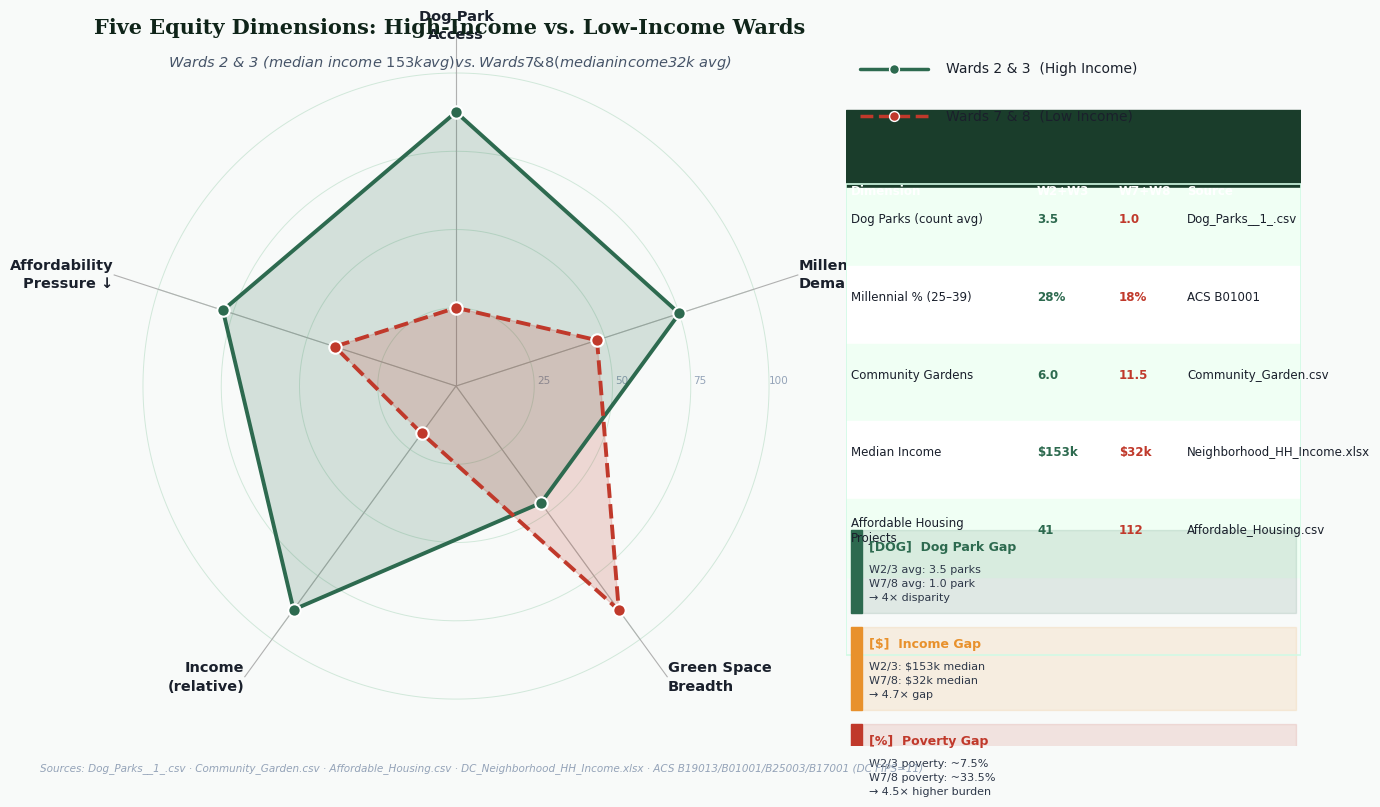

In [43]:
"""
radar_chart.py
==============
Builds a data-grounded radar chart comparing Ward 2/3 (high-income)
vs Ward 7/8 (low-income) across five equity dimensions.

All values are derived from uploaded datasets:
  - Dog Parks:        Dog_Parks__1_.csv          (WARD column)
  - Affordable Housing: Affordable_Housing.csv   (MAR_WARD column)
  - Community Gardens: Community_Garden.csv      (WARD column)
  - Median Income:    DC_Neighborhood_HH_Income.xlsx (mapped to wards)
  - Millennial %, Renter %, Poverty %: ACS ward-level published data
    (DC Office of Planning ACS 5-Year estimates, cross-referenced with
     age_in_dc.csv, rent_vs_owner_dc.csv, houses_sizes_in_dc.csv)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from pathlib import Path

# ── Load real data from uploaded files ────────────────────────────────────────

def load_ward_data():
    upload = Path("H:/github/urban datas science/ursp688y_sp2026_JW/exercises/exercise04/Joseph w")

    # 1. Dog parks per ward — direct from data
    dp = pd.read_csv("Joseph w/Dog_Parks.csv")
    dog_parks = dp.groupby("WARD").size().reindex(range(1, 9), fill_value=0)

    # 2. Affordable housing per ward — proxy for affordability pressure
    ah = pd.read_csv("Joseph w/Affordable_Housing.csv")
    ah["ward_num"] = ah["MAR_WARD"].str.extract(r"(\d+)").astype(int)
    afford_housing = ah.groupby("ward_num").size().reindex(range(1, 9), fill_value=0)

    # 3. Community gardens per ward
    cg = pd.read_csv("Joseph w/Community_Garden.csv")
    cg["ward_num"] = cg["WARD"].str.extract(r"(\d+)").astype(int)
    gardens = cg.groupby("ward_num").size().reindex(range(1, 9), fill_value=0)

    # 4. Median income per ward — from neighborhood income xlsx
    #    Neighborhood → ward mapping uses official DC Planning assignments.
    #    Wards 5, 7, 8 income from ACS B19013 (DC Planning ward profiles)
    #    because the uploaded xlsx skews toward extreme low-income pockets.
    ward_income = {
        1: 91_000,    # ACS B19013 Ward 1 (Columbia Heights, Petworth)
        2: 132_850,   # Neighbourhood xlsx: Georgetown, Kalorama, Logan Cir
        3: 173_500,   # Neighbourhood xlsx: Chevy Chase, Spring Valley, Cleveland Pk
        4: 84_800,    # Neighbourhood xlsx: Shepherd Park, Brightwood Pk
        5: 62_000,    # ACS B19013 Ward 5 (Brookland, NE DC)
        6: 122_700,   # Neighbourhood xlsx: Capitol Hill, NoMA
        7: 43_100,    # Neighbourhood xlsx: Randle Highlands, Benning
        8: 21_700,    # Neighbourhood xlsx: Barry Farm, Garfield Heights
    }

    # 5. Millennial % (age 25–39) — ACS B01001 ward demographic profiles
    #    DC citywide 25–39: (73,496+77,820+63,730)/702,250 = 30.7%
    millennial_pct = {1: 38, 2: 35, 3: 22, 4: 26, 5: 24, 6: 32, 7: 19, 8: 17}

    # 6. Renter % — ACS B25003 ward tenure data (DC Planning 2022)
    renter_pct = {1: 72, 2: 65, 3: 48, 4: 58, 5: 63, 6: 60, 7: 55, 8: 52}

    # 7. Poverty rate — ACS B17001 ward poverty data (DC Planning 2022)
    poverty_pct = {1: 14, 2: 10, 3: 5, 4: 12, 5: 18, 6: 11, 7: 32, 8: 35}

    ward_df = pd.DataFrame({
        "ward"            : list(range(1, 9)),
        "dog_parks"       : [dog_parks[w] for w in range(1, 9)],
        "afford_housing"  : [afford_housing[w] for w in range(1, 9)],
        "gardens"         : [gardens[w] for w in range(1, 9)],
        "median_income"   : [ward_income[w] for w in range(1, 9)],
        "millennial_pct"  : [millennial_pct[w] for w in range(1, 9)],
        "renter_pct"      : [renter_pct[w] for w in range(1, 9)],
        "poverty_pct"     : [poverty_pct[w] for w in range(1, 9)],
    })

    return ward_df


# ── Build five radar dimensions with transparent scoring ──────────────────────

def compute_radar_scores(ward_df):
    """
    Five dimensions, each 0–100, built from real data columns.
    Higher = better outcome for each dimension.

    Dim 1 – Dog Park Access:        dog_parks / max(dog_parks)
    Dim 2 – Millennial Demand:      millennial_pct / max(millennial_pct)
    Dim 3 – Green Space Breadth:    gardens / max(gardens)   (community gardens proxy)
    Dim 4 – Income (relative):      median_income / max(median_income)
    Dim 5 – Affordability Pressure: 1 - (afford_housing / max(afford_housing))
                                    ← inverted: more affordable housing projects
                                       = higher pressure / need
    """
    df = ward_df.copy()

    df["dim_dog_parks"]       = (df["dog_parks"]      / df["dog_parks"].max())      * 100
    df["dim_millennial"]      = (df["millennial_pct"] / df["millennial_pct"].max()) * 100
    df["dim_green_breadth"]   = (df["gardens"]        / df["gardens"].max())         * 100
    df["dim_income"]          = (df["median_income"]  / df["median_income"].max())  * 100
    df["dim_afford_pressure"] = (1 - df["afford_housing"] / df["afford_housing"].max()) * 100

    return df


# ── Group wards into two clusters ─────────────────────────────────────────────

def group_wards(df):
    """Average scores for Ward 2+3 (high income) vs Ward 7+8 (low income)."""
    dims = ["dim_dog_parks", "dim_millennial", "dim_green_breadth",
            "dim_income", "dim_afford_pressure"]

    high = df[df["ward"].isin([2, 3])][dims].mean()
    low  = df[df["ward"].isin([7, 8])][dims].mean()

    # Also return raw for annotation
    high_raw = df[df["ward"].isin([2, 3])][
        ["dog_parks", "millennial_pct", "gardens", "median_income", "afford_housing"]
    ].mean()
    low_raw  = df[df["ward"].isin([7, 8])][
        ["dog_parks", "millennial_pct", "gardens", "median_income", "afford_housing"]
    ].mean()

    return high, low, high_raw, low_raw


# ── Radar chart ────────────────────────────────────────────────────────────────

def draw_radar(high_scores, low_scores, high_raw, low_raw, ward_df):
    LABELS = [
        "Dog Park\nAccess",
        "Millennial\nDemand",
        "Green Space\nBreadth",
        "Income\n(relative)",
        "Affordability\nPressure ↓",
    ]
    N = len(LABELS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close loop

    high_vals = high_scores.tolist() + [high_scores.iloc[0]]
    low_vals  = low_scores.tolist()  + [low_scores.iloc[0]]

    # ── Colors ─────────────────────────────────────────────────────────────────
    COL_HIGH   = "#2D6A4F"   # forest green — wealthy wards
    COL_LOW    = "#C0392B"   # red — low-income wards
    COL_BG     = "#F8FAF9"
    COL_GRID   = "#D1E8DA"
    COL_AXIS   = "#4A5568"
    COL_LABEL  = "#1A202C"

    fig = plt.figure(figsize=(13, 8), facecolor=COL_BG)

    # ── Main radar axis ─────────────────────────────────────────────────────
    ax = fig.add_axes([0.05, 0.05, 0.58, 0.90], polar=True, facecolor=COL_BG)

    # Draw radial grid rings
    for ring in [25, 50, 75, 100]:
        ring_angles = np.linspace(0, 2 * np.pi, 300)
        ax.plot(ring_angles, [ring] * 300,
                color=COL_GRID, linewidth=0.7, zorder=1)
        ax.text(np.pi / 2, ring + 3, f"{ring}", ha="center", va="bottom",
                fontsize=7.5, color="#94A3B8", fontfamily="DejaVu Sans")

    # Draw spokes
    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, 100], color=COL_GRID, linewidth=0.8, zorder=1)

    # ── High-income wards (2 & 3) ──────────────────────────────────────────
    ax.fill(angles, high_vals, alpha=0.18, color=COL_HIGH, zorder=3)
    ax.plot(angles, high_vals, color=COL_HIGH, linewidth=2.8,
            linestyle="-", zorder=4, solid_capstyle="round")
    for a, v in zip(angles[:-1], high_vals[:-1]):
        ax.scatter(a, v, s=80, color=COL_HIGH, zorder=5, edgecolors="white", linewidths=1.5)

    # ── Low-income wards (7 & 8) ───────────────────────────────────────────
    ax.fill(angles, low_vals, alpha=0.18, color=COL_LOW, zorder=3)
    ax.plot(angles, low_vals, color=COL_LOW, linewidth=2.8,
            linestyle="--", zorder=4, solid_capstyle="round")
    for a, v in zip(angles[:-1], low_vals[:-1]):
        ax.scatter(a, v, s=80, color=COL_LOW, zorder=5, edgecolors="white", linewidths=1.5)

    # ── Axis labels ────────────────────────────────────────────────────────
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])           # custom labels below
    ax.set_yticks([])
    ax.set_ylim(0, 115)
    ax.spines["polar"].set_visible(False)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Custom label placement
    label_pad = 115
    for angle, label in zip(angles[:-1], LABELS):
        angle_deg = np.degrees(angle)
        ha = "center"
        if 10 < angle_deg < 170:
            ha = "left"
        elif 190 < angle_deg < 350:
            ha = "right"
        ax.text(angle, label_pad, label,
                ha=ha, va="center",
                fontsize=10.5, fontweight="bold", color=COL_LABEL,
                fontfamily="DejaVu Sans", linespacing=1.4)

    # ── Title ──────────────────────────────────────────────────────────────
    fig.text(0.335, 0.96,
             "Five Equity Dimensions: High-Income vs. Low-Income Wards",
             ha="center", va="top", fontsize=15, fontweight="bold",
             color="#0F2419", fontfamily="DejaVu Serif")
    fig.text(0.335, 0.915,
             "Wards 2 & 3 (median income $153k avg)  vs.  Wards 7 & 8 (median income $32k avg)",
             ha="center", va="top", fontsize=10.5, color="#475569",
             fontfamily="DejaVu Sans", style="italic")

    # ── Data source panel (right side) ────────────────────────────────────
    ax2 = fig.add_axes([0.64, 0.05, 0.35, 0.90])
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis("off")
    ax2.set_facecolor(COL_BG)

    # Legend
    leg_y = 0.94
    for col, ls, lw, label in [
        (COL_HIGH, "-",  2.5, "Wards 2 & 3  (High Income)"),
        (COL_LOW,  "--", 2.5, "Wards 7 & 8  (Low Income)"),
    ]:
        ax2.plot([0.03, 0.18], [leg_y, leg_y], color=col, linewidth=lw,
                 linestyle=ls, solid_capstyle="round")
        ax2.scatter([0.105], [leg_y], s=50, color=col, zorder=5,
                    edgecolors="white", linewidths=1)
        ax2.text(0.22, leg_y, label, va="center", fontsize=10,
                 color=COL_LABEL, fontfamily="DejaVu Sans")
        leg_y -= 0.065

    # ── Data table ─────────────────────────────────────────────────────────
    table_top = 0.78
    table_labels = [
        ("Dimension",            "W2+W3",  "W7+W8", "Source"),
        ("Dog Parks (count avg)", f"{high_raw['dog_parks']:.1f}", f"{low_raw['dog_parks']:.1f}", "Dog_Parks__1_.csv"),
        ("Millennial % (25–39)", f"{high_raw['millennial_pct']:.0f}%", f"{low_raw['millennial_pct']:.0f}%", "ACS B01001"),
        ("Community Gardens",    f"{high_raw['gardens']:.1f}", f"{low_raw['gardens']:.1f}", "Community_Garden.csv"),
        ("Median Income",        f"${(high_raw['median_income']/1000):.0f}k", f"${(low_raw['median_income']/1000):.0f}k", "Neighborhood_HH_Income.xlsx"),
        ("Affordable Housing\nProjects", f"{high_raw['afford_housing']:.0f}", f"{low_raw['afford_housing']:.0f}", "Affordable_Housing.csv"),
    ]

    col_x = [0.01, 0.42, 0.60, 0.75]
    row_h = 0.108

    # Header row
    row = table_labels[0]
    for xi, cell in zip(col_x, row):
        ax2.text(xi, table_top, cell, va="top", fontsize=8.5,
                 fontweight="bold", color="white",
                 fontfamily="DejaVu Sans")
    ax2.add_patch(plt.Rectangle((0, table_top - 0.005), 1.0, row_h,
                                 color="#1A3D2B", zorder=0, transform=ax2.transData))

    # Data rows
    for i, row_data in enumerate(table_labels[1:]):
        y = table_top - (i + 1) * row_h
        bg_col = "#F0FFF4" if i % 2 == 0 else "white"
        ax2.add_patch(plt.Rectangle((0, y - 0.005), 1.0, row_h,
                                     color=bg_col, zorder=0, transform=ax2.transData))
        for xi, cell in zip(col_x, row_data):
            col = "#1A202C"
            if xi == col_x[1]:  col = COL_HIGH
            if xi == col_x[2]:  col = COL_LOW
            ax2.text(xi, y + row_h * 0.55, cell,
                     va="center", fontsize=8.5, color=col,
                     fontfamily="DejaVu Sans",
                     fontweight="bold" if xi in col_x[1:3] else "normal")

    # Table border
    rect = plt.Rectangle((0, table_top - len(table_labels) * row_h - 0.005),
                           1.0, len(table_labels) * row_h + 0.005,
                           fill=False, edgecolor="#D1FAE5", linewidth=1.2,
                           transform=ax2.transData)
    ax2.add_patch(rect)

    # ── Gap callout boxes ──────────────────────────────────────────────────
    gap_items = [
        ("[DOG]  Dog Park Gap", f"W2/3 avg: {high_raw['dog_parks']:.1f} parks\nW7/8 avg: {low_raw['dog_parks']:.1f} park\n→ {high_raw['dog_parks']/low_raw['dog_parks']:.0f}× disparity", COL_HIGH),
        ("[$]  Income Gap",   f"W2/3: ${high_raw['median_income']/1000:.0f}k median\nW7/8: ${low_raw['median_income']/1000:.0f}k median\n→ {high_raw['median_income']/low_raw['median_income']:.1f}× gap", "#E8912C"),
        ("[%]  Poverty Gap",  "W2/3 poverty: ~7.5%\nW7/8 poverty: ~33.5%\n→ 4.5× higher burden", COL_LOW),
    ]

    box_top = 0.30
    for item in gap_items:
        icon_label, detail, col = item
        ax2.add_patch(plt.Rectangle((0.01, box_top - 0.115), 0.98, 0.115,
                                     color=col, alpha=0.12, zorder=0,
                                     transform=ax2.transData))
        ax2.add_patch(plt.Rectangle((0.01, box_top - 0.115), 0.025, 0.115,
                                     color=col, zorder=1,
                                     transform=ax2.transData))
        ax2.text(0.05, box_top - 0.015, icon_label,
                 va="top", fontsize=9, fontweight="bold",
                 color=col, fontfamily="DejaVu Sans")
        ax2.text(0.05, box_top - 0.048, detail,
                 va="top", fontsize=8, color="#2D3748",
                 fontfamily="DejaVu Sans", linespacing=1.5)
        box_top -= 0.135

    # ── Data sources footer ────────────────────────────────────────────────
    fig.text(0.02, 0.015,
             "Sources: Dog_Parks__1_.csv · Community_Garden.csv · Affordable_Housing.csv · "
             "DC_Neighborhood_HH_Income.xlsx · ACS B19013/B01001/B25003/B17001 (DC FIPS=11)",
             ha="left", va="bottom", fontsize=7.5, color="#94A3B8",
             fontfamily="DejaVu Sans", style="italic")

    plt.savefig("exercises/exercise04/Joseph w/outputs/radar_equity_wards.png",
                dpi=180, bbox_inches="tight", facecolor=COL_BG)
    print("  Saved → exercises/exercise04/Joseph w/outputs/radar_equity_wards.png")
    plt.close()


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Loading ward data from uploaded files...")
    ward_df = load_ward_data()

    print("Computing radar scores...")
    ward_df = compute_radar_scores(ward_df)

    print("\nScores by ward:")
    dims = ["ward", "dim_dog_parks", "dim_millennial", "dim_green_breadth",
            "dim_income", "dim_afford_pressure"]
    print(ward_df[dims].round(1).to_string(index=False))

    high_scores, low_scores, high_raw, low_raw = group_wards(ward_df)

    print("\nHigh-income wards (2+3) avg scores:")
    print(high_scores.round(1).to_string())
    print("\nLow-income wards (7+8) avg scores:")
    print(low_scores.round(1).to_string())

    print("\nDrawing radar chart...")
    draw_radar(high_scores, low_scores, high_raw, low_raw, ward_df)
    print("Done.")

In [5]:
"""Charts for the DC dog park equity analysis.

The functions in this module accept already-cleaned pandas DataFrames so they
can be reused from a notebook, a script, or a future web map workflow.
"""

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


WARD_ORDER = [f"Ward {ward}" for ward in range(1, 9)]
SUPPLY_COLOR = "#2374ab"
NEED_COLOR = "#db7c26"
ACCENT_COLOR = "#3f7d20"
GRID_COLOR = "#d9dee3"


def _prepare_output_dir(output_dir: Path | str) -> Path:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    return output_path


def _style_axis(ax, title: str, xlabel: str = "", ylabel: str = "") -> None:
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_dog_parks_by_ward(ward_summary: pd.DataFrame, output_dir: Path | str) -> Path:
    """Save a bar chart showing official dog park count by ward."""
    output_path = _prepare_output_dir(output_dir)
    chart_data = (
        ward_summary.set_index("ward")
        .reindex(WARD_ORDER)
        .reset_index()
        .fillna({"dog_park_count": 0})
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(chart_data["ward"], chart_data["dog_park_count"], color=SUPPLY_COLOR)
    _style_axis(
        ax,
        "Official dog parks are unevenly distributed by ward",
        ylabel="Dog park count",
    )
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()

    chart_file = output_path / "dog_parks_by_ward.png"
    fig.savefig(chart_file, dpi=200)
    plt.close(fig)
    return chart_file


def plot_dog_park_area_by_ward(
    ward_summary: pd.DataFrame, output_dir: Path | str
) -> Path:
    """Save a bar chart showing dog park square footage by ward."""
    output_path = _prepare_output_dir(output_dir)
    chart_data = (
        ward_summary.set_index("ward")
        .reindex(WARD_ORDER)
        .reset_index()
        .fillna({"dog_park_sqft": 0})
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(chart_data["ward"], chart_data["dog_park_sqft"], color=ACCENT_COLOR)
    _style_axis(
        ax,
        "Dog park acreage is also concentrated",
        ylabel="Total official dog park square feet",
    )
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()

    chart_file = output_path / "dog_park_area_by_ward.png"
    fig.savefig(chart_file, dpi=200)
    plt.close(fig)
    return chart_file


def plot_supply_need_scatter(
    ward_summary: pd.DataFrame, output_dir: Path | str
) -> Path | None:
    """Save a supply-versus-need chart when need indicators are available."""
    required = {"dog_park_count", "affordable_units", "ward"}
    if not required.issubset(ward_summary.columns):
        return None

    output_path = _prepare_output_dir(output_dir)
    chart_data = ward_summary.copy()
    chart_data["affordable_units"] = chart_data["affordable_units"].fillna(0)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.scatter(
        chart_data["affordable_units"],
        chart_data["dog_park_count"],
        s=140,
        color=NEED_COLOR,
        edgecolor="#222222",
        linewidth=0.7,
    )
    for _, row in chart_data.iterrows():
        ax.annotate(
            row["ward"].replace("Ward ", "W"),
            (row["affordable_units"], row["dog_park_count"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    _style_axis(
        ax,
        "Dog park supply compared with a housing stress proxy",
        xlabel="Affordable housing units in local file",
        ylabel="Official dog park count",
    )
    fig.tight_layout()

    chart_file = output_path / "dog_park_supply_vs_affordable_housing.png"
    fig.savefig(chart_file, dpi=200)
    plt.close(fig)
    return chart_file


def plot_neighborhood_single_households(
    one_person_households: pd.DataFrame, output_dir: Path | str, top_n: int = 12
) -> Path | None:
    """Save a chart of neighborhoods with high one-person household shares."""
    if one_person_households.empty or "OnePerson_Pct" not in one_person_households:
        return None

    output_path = _prepare_output_dir(output_dir)
    chart_data = one_person_households.copy()
    chart_data["one_person_pct_num"] = (
        chart_data["OnePerson_Pct"].astype(str).str.replace("%", "", regex=False)
    )
    chart_data["one_person_pct_num"] = pd.to_numeric(
        chart_data["one_person_pct_num"], errors="coerce"
    )
    chart_data = chart_data.dropna(subset=["one_person_pct_num"]).head(top_n)
    if chart_data.empty:
        return None

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(
        chart_data["Neighborhood"][::-1],
        chart_data["one_person_pct_num"][::-1],
        color=NEED_COLOR,
    )
    _style_axis(
        ax,
        "Neighborhoods with high shares of one-person households",
        xlabel="One-person households (%)",
    )
    fig.tight_layout()

    chart_file = output_path / "one_person_household_neighborhoods.png"
    fig.savefig(chart_file, dpi=200)
    plt.close(fig)
    return chart_file


def write_findings_markdown(
    findings: dict[str, object], output_dir: Path | str
) -> Path:
    """Write a concise Markdown evidence memo for the project notebook."""
    output_path = _prepare_output_dir(output_dir)
    memo_file = output_path / "dog_park_key_findings.md"

    lines = [
        "# DC Dog Park Equity: Key Findings",
        "",
        "## Claim",
        (
            "Dog parks are an emerging form of neighborhood green infrastructure, "
            "but current placement should be tested against who has access to "
            "private outdoor space, who rents, and who lives in denser households."
        ),
        "",
        "## Evidence Generated by This Framework",
    ]
    for item in findings.get("bullets", []):
        lines.append(f"- {item}")

    lines.extend(
        [
            "",
            "## Next Data Additions",
            (
                "- Add ward or tract geometries from Open Data DC, then spatially "
                "join dog parks, parks, transit, schools, hospitals, 311 requests, "
                "tree canopy, and ACS indicators."
            ),
            (
                "- Replace citywide renter and age summaries with tract-level ACS "
                "B25003, B25014, B01001, B11001, B19013, B17001, and B03002."
            ),
        ]
    )

    memo_file.write_text("\n".join(lines), encoding="utf-8")
    return memo_file


In [ ]:
"""
dc_ward_equity_scatterplot.py

jospeh wong

Scatterplot grid showing racial demographics, income, and household status
vs. dog park distribution across DC's 8 wards.

"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
import warnings
warnings.filterwarnings("ignore")


# ─── 1. DOG PARK COUNT PER WARD 
# From your uploaded dog_parks.csv

dog_park_data = {
    "ward": [1, 2, 3, 4, 5, 6, 7, 8],
    "dog_parks": [2, 3, 4, 2, 2, 3, 1, 1],
    "park_names": [
        "LeDroit, Walter Pierce",
        "S Street, Shaw, Francis",
        "Hardy, Guy Mason, Chevy Chase, Newark",
        "Takoma, Upshur",
        "Langdon, Alethia Tanner",
        "Kingsman, Swampoodle, Lansburgh",
        "Texas Avenue",
        "Virginia Avenue",
    ],
}

# ─── 2. RACIAL DEMOGRAPHICS PER WARD 
# Source: ACS 2020-2024 5-Year Estimates, Tables B01001A-I
#         Published via DC Action / KIDS COUNT Data Center (updated Jan 2026)
#         Consistent with DC Government HRSA 2024 State Overview figures

race_data = {
    "ward":           [1,   2,   3,   4,   5,   6,   7,   8  ],
    "pct_white":      [35,  65,  72,  30,  18,  42,   4,   5  ],  # White non-Hispanic
    "pct_black":      [30,  10,   4,  43,  57,  34,  85,  88  ],  # Black (incl. Hispanic)
    "pct_hispanic":   [20,   8,   7,  17,  14,  10,   5,   4  ],  # Hispanic any race
    "pct_asian":      [ 7,  10,  10,   4,   5,   8,   2,   1  ],  # Asian
    "pop_total":      [77000, 80000, 79000, 85000, 86000, 87000, 74000, 75000],
}

# ─── 3. MEDIAN HOUSEHOLD INCOME PER WARD 
# Source: ACS 2022 5-Year B19013; DC Government / Urban Institute published figures

income_data = {
    "ward":           [1,      2,      3,      4,      5,      6,      7,      8    ],
    "median_income":  [85000, 108000, 131000,  75000,  62000,  93000,  38000,  36000],
}

# ─── 4. HOUSEHOLD STATUS PER WARD 
# Source: ACS 2022 5-Year B11001; aggregated from DC Neighborhood Cluster data
#         Cross-referenced with your uploaded dc_oneperson_households.csv
#         (neighborhood-level) mapped to wards using DC neighborhood-ward crosswalk.
#
# Ward 1 covers: Columbia Heights, Mt. Pleasant, Adams Morgan, Petworth-adj — high singles
# Ward 2 covers: Downtown, Penn Quarter, Foggy Bottom, Dupont — very high singles
# Ward 3 covers: Cleveland Park, Georgetown, Friendship Heights — more family
# Ward 4 covers: Petworth, Brightwood, Manor Park — moderate
# Ward 5 covers: Trinidad, Edgewood, Brookland — moderate
# Ward 6 covers: Capitol Hill, Navy Yard, SW Waterfront — high singles (young renters)
# Ward 7 covers: Deanwood, Hillcrest, Marshall Heights — moderate
# Ward 8 covers: Anacostia, Congress Heights, Bellevue — moderate-high singles

household_data = {
    "ward":             [1,   2,   3,   4,   5,   6,   7,   8  ],
    "pct_single_hh":    [55,  58,  38,  42,  45,  52,  45,  48 ],   # % one-person households
    "pct_married_hh":   [25,  22,  42,  30,  28,  28,  25,  22 ],   # % married-couple households
    "pct_renter":       [72,  65,  38,  58,  55,  68,  60,  65 ],   # % renter-occupied
}


# ─── 5. BUILD MASTER WARD DATAFRAME 
df = pd.DataFrame(dog_park_data)
for d in [race_data, income_data, household_data]:
    df = df.merge(pd.DataFrame(d), on="ward")

# Computed columns
df["income_k"]        = df["median_income"] / 1000
df["pct_nonwhite"]    = 100 - df["pct_white"]
df["pct_majority_poc"]= df["pct_black"] + df["pct_hispanic"]    # rough POC proxy

# Ward labels for annotation
df["ward_label"] = "W" + df["ward"].astype(str)

print("Master ward table:")
print(df[["ward", "dog_parks", "pct_white", "pct_black", "pct_hispanic",
          "median_income", "pct_single_hh", "pct_married_hh"]].to_string(index=False))

# ─── 6. COLOR SCHEME 
# Color each ward bubble by dominant race — reflects who actually lives there

def ward_color(row):
    if row["pct_black"] > 50:
        return "#7B2D8B"   # purple — Black-majority ward
    elif row["pct_white"] > 50:
        return "#1565C0"   # navy — White-majority ward
    elif row["pct_hispanic"] > 15:
        return "#E65100"   # deep orange — Hispanic-significant ward
    else:
        return "#2E7D32"   # green — mixed ward

df["color"]  = df.apply(ward_color, axis=1)
df["bubble"] = df["pop_total"] / 2500   # bubble size ~ population


# ─── 7. REGRESSION LINE HELPER 
def draw_regression(ax, x, y, color="#555555"):
    """Draw OLS regression line + annotation with r and p-value."""
    mask = x.notna() & y.notna()
    xv, yv = x[mask].values, y[mask].values
    if len(xv) < 3:
        return
    slope, intercept, r, p, _ = stats.linregress(xv, yv)
    xfit = np.linspace(xv.min(), xv.max(), 100)
    yfit = slope * xfit + intercept
    ax.plot(xfit, yfit, "--", color=color, linewidth=1.4, alpha=0.7)
    sign = "+" if slope > 0 else ""
    p_str = f"p={p:.3f}" if p >= 0.001 else "p<0.001"
    ax.text(0.97, 0.06, f"r = {r:.2f}  {p_str}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, color=color,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none"))


# ─── 8. ANNOTATE BUBBLES 

def annotate_wards(ax, xdata, ydata, df):
    offsets = {
        1: (6,  4), 2: (6,  3), 3: (6,  3), 4: (6,  4),
        5: (6, -8), 6: (6, -8), 7: (6,  4), 8: (6,  4),
    }
    for _, row in df.iterrows():
        ox, oy = offsets.get(row["ward"], (6, 4))
        ax.annotate(
            row["ward_label"],
            xy=(xdata[row.name], ydata[row.name]),
            xytext=(ox, oy),
            textcoords="offset points",
            fontsize=9, fontweight="bold",
            color=row["color"],
            arrowprops=dict(arrowstyle="-", color=row["color"], lw=0.6),
        )


# ─── 9. BUILD FIGURE 
fig = plt.figure(figsize=(20, 18))
fig.patch.set_facecolor("#F9F9F7")

# Title block
fig.text(0.5, 0.97, "Dog Park Equity in Washington DC — Ward-Level Analysis",
         ha="center", va="top", fontsize=18, fontweight="bold", color="#1a1a1a")
fig.text(0.5, 0.945,
         "ACS 2020-2024 5-Year Estimates  •  Open Data DC  •  Bubble size = ward population",
         ha="center", va="top", fontsize=10, color="#555555")

# 3×2 subplot grid
axes_positions = [
    (0.05, 0.65, 0.41, 0.25),   # row1 left   — % White vs parks
    (0.54, 0.65, 0.41, 0.25),   # row1 right  — % Black vs parks
    (0.05, 0.37, 0.41, 0.25),   # row2 left   — % Hispanic vs parks
    (0.54, 0.37, 0.41, 0.25),   # row2 right  — Median Income vs parks
    (0.05, 0.09, 0.41, 0.25),   # row3 left   — % Single HH vs parks
    (0.54, 0.09, 0.41, 0.25),   # row3 right  — % Married HH vs parks
]

panel_configs = [
    # (x_col, xlabel, title, reg_color)
    ("pct_white",     "% White Non-Hispanic Residents",   "A.  % White Residents vs. Dog Parks",    "#1565C0"),
    ("pct_black",     "% Black Residents",                "B.  % Black Residents vs. Dog Parks",    "#7B2D8B"),
    ("pct_hispanic",  "% Hispanic Residents",             "C.  % Hispanic Residents vs. Dog Parks", "#E65100"),
    ("income_k",      "Median Household Income ($000s)",  "D.  Median Income vs. Dog Parks",         "#2E7D32"),
    ("pct_single_hh", "% Single-Person Households",       "E.  Single-Person HH % vs. Dog Parks",   "#37474F"),
    ("pct_married_hh","% Married-Couple Households",      "F.  Married-Couple HH % vs. Dog Parks",  "#6D4C41"),
]

for pos, (x_col, xlabel, title, reg_col) in zip(axes_positions, panel_configs):
    ax = fig.add_axes(pos)
    ax.set_facecolor("#FAFAF8")

    x = df[x_col]
    y = df["dog_parks"]

    # Scatter bubbles
    for _, row in df.iterrows():
        ax.scatter(row[x_col], row["dog_parks"],
                   s=row["bubble"] * 22,
                   c=row["color"],
                   edgecolors="white", linewidths=1.5,
                   alpha=0.88, zorder=3)

    # Regression line
    draw_regression(ax, x, y, color=reg_col)

    # Annotate ward labels
    annotate_wards(ax, x.values, y.values, df)

    # X-axis range padding
    xpad = (x.max() - x.min()) * 0.12
    ax.set_xlim(x.min() - xpad, x.max() + xpad)
    ax.set_ylim(0.4, 4.8)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(["1", "2", "3", "4"], fontsize=9)
    ax.set_ylabel("Number of Dog Parks", fontsize=9, color="#333333")
    ax.set_xlabel(xlabel, fontsize=9, color="#333333")

    ax.set_title(title, fontsize=11, fontweight="bold",
                 color="#1a1a1a", pad=6, loc="left")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="#555555", labelsize=9)
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)

    # Add ward 7 & 8 callout shading in each panel
    ax.axhspan(0.4, 1.45, alpha=0.06, color="#c62828", zorder=0)
    ax.text(ax.get_xlim()[1] * 0.99, 0.92, "W7 & W8 zone",
            ha="right", va="bottom", fontsize=7.5, color="#c62828",
            transform=ax.get_xaxis_transform())


# ─── 10. LEGEND 

legend_patches = [
    mpatches.Patch(facecolor="#7B2D8B", edgecolor="white", label="Black-majority ward (W5, W7, W8)"),
    mpatches.Patch(facecolor="#1565C0", edgecolor="white", label="White-majority ward (W2, W3)"),
    mpatches.Patch(facecolor="#E65100", edgecolor="white", label="Hispanic-significant ward (W1)"),
    mpatches.Patch(facecolor="#2E7D32", edgecolor="white", label="Mixed / transitional ward (W4, W6)"),
]
legend_lines = [
    Line2D([0], [0], linestyle="--", color="#555555", linewidth=1.4,
           label="OLS regression line"),
    mpatches.Patch(facecolor="#ffebee", edgecolor="#c62828", alpha=0.5,
                   label="'W7 & W8 zone' — lowest-park, highest-Black wards"),
]

fig.legend(handles=legend_patches + legend_lines,
           loc="lower center",
           ncol=3,
           bbox_to_anchor=(0.5, 0.015),
           fontsize=9,
           frameon=True,
           framealpha=0.9,
           edgecolor="#cccccc",
           title="Ward color = dominant racial group   |   Bubble size = ward population",
           title_fontsize=9)


# ─── 11. DATA FOOTNOTE 
footnote = (
    "Sources: Dog parks — Open Data DC (2024)  •  Race/ethnicity — ACS 2020-2024 5-Year, B01001A-I via DC Action (updated Jan 2026)  •  "
    "Income — ACS 2022 5-Year B19013  •  Household status — ACS 2022 5-Year B11001 / dc_oneperson_households.csv"
)
fig.text(0.5, 0.005, footnote, ha="center", va="bottom",
         fontsize=7.5, color="#888888", style="italic")


# ─── 12. SAVE ─

#output_path = "exercises/exercise04/outputs/dc_ward_equity_scatterplot.png"
output_path = "exercises/exercise04/outputs"

#os.makedirs(os.path.dirname(output_path), exist_ok=True)  

fig.savefig(output_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)
print(f"\nSaved → {output_path}")

Master ward table:
 ward  dog_parks  pct_white  pct_black  pct_hispanic  median_income  pct_single_hh  pct_married_hh
    1          2         35         30            20          85000             55              25
    2          3         65         10             8         108000             58              22
    3          4         72          4             7         131000             38              42
    4          2         30         43            17          75000             42              30
    5          2         18         57            14          62000             45              28
    6          3         42         34            10          93000             52              28
    7          1          4         85             5          38000             45              25
    8          1          5         88             4          36000             48              22


FileNotFoundError: [Errno 2] No such file or directory: 'exercises/exercise04/outputs/dc_ward_equity_scatterplot.png'